In [2]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
import numpy as np
import pyarrow.dataset as ds
import polars as pl
import geopandas as gpd
import reverse_geocode
from src.damages.damage_functions import emanuel_2011
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [3]:
litpop_dir = Path("data/input/wealth_densities/litpop/5 minutes")
litpop = pd.concat([pd.read_hdf(fpath) for fpath in litpop_dir.glob("*.hdf5")], axis=0,ignore_index=True)
litpop = gpd.GeoDataFrame(litpop, geometry="geometry", crs="EPSG:4326")

In [4]:
litpop

,value,latitude,longitude,geometry,region_id,impf_
0,0.000000,51.375000,-178.958333,POINT (-178.95833 51.375),840,1
1,0.000000,51.875000,-178.208333,POINT (-178.20833 51.875),840,1
2,0.000000,51.875000,-178.125000,POINT (-178.125 51.875),840,1
3,0.000000,51.875000,-178.041667,POINT (-178.04167 51.875),840,1
4,0.000000,51.875000,-177.958333,POINT (-177.95833 51.875),840,1
...,...,...,...,...,...,...
160780,0.000000,52.875000,173.041667,POINT (173.04167 52.875),840,1
160781,4348.029150,52.875000,173.125000,POINT (173.125 52.875),840,1
160782,29688.926871,52.875000,173.208333,POINT (173.20833 52.875),840,1
160783,0.000000,52.791667,172.791667,POINT (172.79167 52.79167),840,1


In [14]:
tracks_dir = Path("data/output/catherina_75_seeds/intensified_tracks/ACCESS-CM2/ssp585")
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")
# tracks_ds = pl.scan_parquet(list(tracks_dir.rglob("*.parquet")), hive_partitioning=True)

In [17]:
output_dir = Path("./data/output/damages/national/.temp")
output_dir.mkdir(parents=True, exist_ok=True)

for year in tqdm(list(range(2025,2100+1))):
    # tracks = tracks_ds.filter(pl.col("year") == year).collect()
    tracks = tracks_ds.to_table(filter=ds.field("year") == year)
    tracks = gpd.GeoDataFrame(tracks.to_pandas(), geometry=gpd.points_from_xy(tracks["lon_left"], tracks["lat_left"]), crs="EPSG:4326")
    impact = gpd.sjoin_nearest(tracks.loc[:,["year", "lat_left", "lon_left", "geometry", "final_wind_speed"]].to_crs("EPSG:3857"), litpop.to_crs("EPSG:3857"))
    # join entre tracks et densité de richesse pour récupérer le point le plus proche de chaque point de track

    impact["relative_losses"] = emanuel_2011(v=impact["final_wind_speed"]) # emanuel_2011 fonction de dommages issue de la littérature
    impact["losses"] = impact["relative_losses"] * impact["value"]
    impact.drop(columns="geometry", inplace=True)
    impact.to_parquet(output_dir / f"{year}.parquet")

  0%|          | 0/76 [00:00<?, ?it/s]

/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(
/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not

In [18]:
output_dir = Path("./data/output/damages/national/.temp/")
# Aggregate
all_losses = pl.read_parquet(output_dir / "*.parquet").to_pandas()

In [19]:
for i in tqdm(list(range(len(all_losses)))):
    lat = all_losses.at[all_losses.index[i], "lat_left"]
    lon = all_losses.at[all_losses.index[i], "lon_left"]
    geo_dict = reverse_geocode.get((lat,lon))
    all_losses.at[all_losses.index[i], "country_code"] = geo_dict["country_code"]
    all_losses.at[all_losses.index[i], "country"] = geo_dict["country"]

  0%|          | 0/21584824 [00:00<?, ?it/s]

In [20]:
all_losses.groupby(["year", "country", "seed"]).agg({"losses": "sum"})

losses
year country        seed         
2025 Afghanistan    11    0.00000
                    15    0.00000
                    64    0.00000
     American Samoa 2     0.00000
                    36    0.13811
...                           ...
2099 Yemen          35    0.00000
                    48    0.00000
                    51    0.00000
                    63    0.00000
                    64    0.00000

[340344 rows x 1 columns]

In [21]:
all_losses

,year,lat_left,lon_left,final_wind_speed,index_right,value,latitude,longitude,region_id,impf_,relative_losses,losses,seed,SID,step,country_code,country
0,2025,12.500484,-106.500000,NaN,160051,8.355823e+08,26.375,-98.875000,840,1,NaN,NaN,0,2119282752,0,MX,Mexico
1,2025,12.461908,-106.572353,20.010991,160051,8.355823e+08,26.375,-98.875000,840,1,0.000000e+00,0.0,0,2119282752,1,MX,Mexico
2,2025,12.434372,-106.662559,18.364960,160051,8.355823e+08,26.375,-98.875000,840,1,0.000000e+00,0.0,0,2119282752,2,MX,Mexico
3,2025,12.417464,-106.769879,15.390588,160051,8.355823e+08,26.375,-98.875000,840,1,0.000000e+00,0.0,0,2119282752,3,MX,Mexico
4,2025,12.410696,-106.893604,16.206913,160051,8.355823e+08,26.375,-98.875000,840,1,0.000000e+00,0.0,0,2119282752,4,MX,Mexico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21584819,2099,48.772760,170.641483,24.224815,160769,0.000000e+00,52.375,173.708333,840,1,0.000000e+00,0.0,9,2119336778,57,RU,Russian Federation
21584820,2099,49.365869,172.564638,26.034558,160769,0.000000e+00,52.375,173.708333,840,1,3.182909e-07,0.0,9,2119336778,58,RU,Russian Federation
21584821,2099,50.012569,174.555771,27.459427,160769,0.000000e+00,52.375,173.708333,840,1,4.629194e-05,0.0,9,2119336778,59,RU,Russian Federation
21584822,2099,50.629251,176.530179,28.994966,160766,0.000000e+00,51.875,177.291667,840,1,3.039714e-04,0.0,9,2119336778,60,RU,Russian Federation


In [ ]:
losses_to_plot = (
    all_losses[all_losses.country_code == "US"]
    .groupby(["year", "country", "seed"], as_index=False)
    .agg({"losses": "sum"})
)

In [38]:
losses_per_year_metrics = (
    losses_to_plot
    .groupby("year", as_index=False)
    .agg(
        mean_losses=("losses", "mean"), 
        p90_losses=("losses", lambda x: np.percentile(x, 90)),
        p95_losses=("losses", lambda x: np.percentile(x, 95))
    )
)

In [39]:
losses_per_year_metrics

,year,mean_losses,p90_losses,p95_losses
0,2025,1.678453e+09,4.068445e+09,8.989374e+09
1,2026,1.892586e+09,4.879295e+09,7.000146e+09
2,2027,1.466703e+09,3.656399e+09,6.516434e+09
3,2028,1.026319e+09,2.305449e+09,4.516950e+09
4,2029,1.017867e+09,1.785474e+09,5.963891e+09
...,...,...,...,...
70,2095,4.319034e+09,7.747524e+09,1.229683e+10
71,2096,5.227942e+09,1.469445e+10,2.728614e+10
72,2097,5.285911e+09,1.680316e+10,2.724557e+10
73,2098,4.289585e+09,1.142346e+10,1.987072e+10


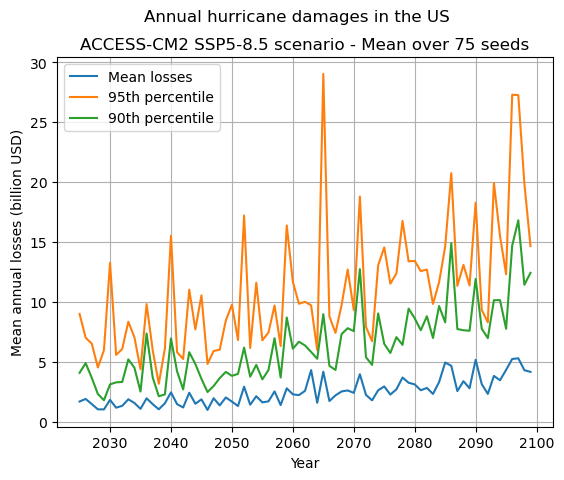

In [45]:
fig, ax = plt.subplots()
ax.plot(losses_per_year_metrics["year"], losses_per_year_metrics["mean_losses"]/1e9)
ax.plot(losses_per_year_metrics["year"], losses_per_year_metrics["p95_losses"]/1e9)
ax.plot(losses_per_year_metrics["year"], losses_per_year_metrics["p90_losses"]/1e9)
plt.xlabel("Year")
plt.ylabel("Mean annual losses (billion USD)")
plt.suptitle("Annual hurricane damages in the US")
plt.title("ACCESS-CM2 SSP5-8.5 scenario - Mean over 75 seeds")
plt.legend(["Mean losses", "95th percentile", "90th percentile"])
plt.grid()
plt.show()

## Ajout ratio de correction

In [46]:
all_losses.head()

,year,lat_left,lon_left,final_wind_speed,index_right,value,latitude,longitude,region_id,impf_,relative_losses,losses,seed,SID,step,country_code,country
0,2025,12.500484,-106.500000,NaN,160051,8.355823e+08,26.375,-98.875,840,1,NaN,NaN,0,2119282752,0,MX,Mexico
1,2025,12.461908,-106.572353,20.010991,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,1,MX,Mexico
2,2025,12.434372,-106.662559,18.364960,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,2,MX,Mexico
3,2025,12.417464,-106.769879,15.390588,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,3,MX,Mexico
4,2025,12.410696,-106.893604,16.206913,160051,8.355823e+08,26.375,-98.875,840,1,0.0,0.0,0,2119282752,4,MX,Mexico


In [62]:
ratio = pd.read_csv("data/input/wealth_densities/ratio_correction/country_rmsf_corr.csv", sep=";")
ratio_US = float(ratio[ratio["iso3"] == "USA"]["correction"].values[0].replace(",", "."))

In [61]:
ratio_US

0.685299803

In [75]:
losses_to_plot_with_ratio = ratio_US * all_losses[
    all_losses.country_code == "US"
].groupby(
    ["year", "country", "seed"]
).agg({"losses": "sum"})

In [ ]:
losses_to_plot_with_ratio

losses
year country       seed              
2025 United States 0     6.430447e+08
                   3     4.420291e+05
                   4     2.278860e+08
                   5     5.706638e+03
                   6     3.018539e+08
...                               ...
2099 United States 70    6.207830e+07
                   71    2.065329e+09
                   72    5.464953e+09
                   73    2.636284e+09
                   74    2.849062e+09

[5610 rows x 1 columns]

In [69]:
losses_per_year_with_ratio_metrics = (
    losses_to_plot_with_ratio
    .groupby("year", as_index=False)
    .agg(
        mean_losses=("losses", "mean"), 
        p90_losses=("losses", lambda x: np.percentile(x, 90)),
        p95_losses=("losses", lambda x: np.percentile(x, 95))
    )
)

/tmp/ipykernel_19338/1010317352.py:4: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(


In [76]:
losses_per_year_with_ratio_metrics

,mean_losses,p90_losses,p95_losses
0,1.150244e+09,2.788104e+09,6.160416e+09
1,1.296989e+09,3.343780e+09,4.797199e+09
2,1.005131e+09,2.505729e+09,4.465711e+09
3,7.033361e+08,1.579924e+09,3.095465e+09
4,6.975441e+08,1.223585e+09,4.087053e+09
...,...,...,...
70,2.959833e+09,5.309377e+09,8.427014e+09
71,3.582708e+09,1.007010e+10,1.869918e+10
72,3.622434e+09,1.151520e+10,1.867139e+10
73,2.939651e+09,7.828492e+09,1.361740e+10


KeyError: 'year'

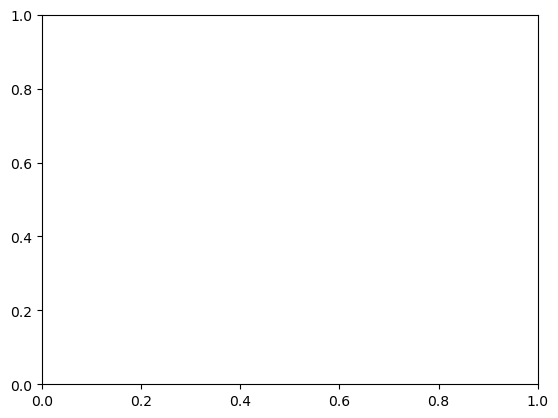

In [67]:
fig, ax = plt.subplots()
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["mean_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p95_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p90_losses"]/1e9)
plt.xlabel("Year")
plt.ylabel("Mean annual losses (billion USD)")
plt.suptitle("Annual hurricane damages in the US")
plt.title("ACCESS-CM2 SSP5-8.5 scenario - Mean over 75 seeds")
plt.legend(["Mean losses", "95th percentile", "90th percentile"])
plt.grid()
plt.show()

## Densité litpop